# Price Optimization ML Pipeline
### 8-Stage Hybrid ML System - Local Reference Implementation

**Input:** `InputData.xlsx` - aggregated quote data (one row per product-market-customer combination)  
**Target:** `Discount` - the negotiated discount percentage  
**Output:** P10/P25/P50/P75/P90 discount guidance bands with SHAP explanations

## Stage 0: Setup & Imports

In [66]:
# !pip install pandas openpyxl matplotlib seaborn scikit-learn xgboost shap numpy

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import re

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.metrics import mean_squared_error, mean_absolute_error

import xgboost as xgb
from xgboost import XGBRegressor
import shap

warnings.filterwarnings('ignore')
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['figure.dpi'] = 100

DATA_FILE = r"C:\AI_Eng_Projects\PriceModel\InputData.xlsx"
RANDOM_STATE = 42
TEST_SIZE = 0.20

## Stage 1: Data Validation

Shape: 64,146 rows x 11 columns


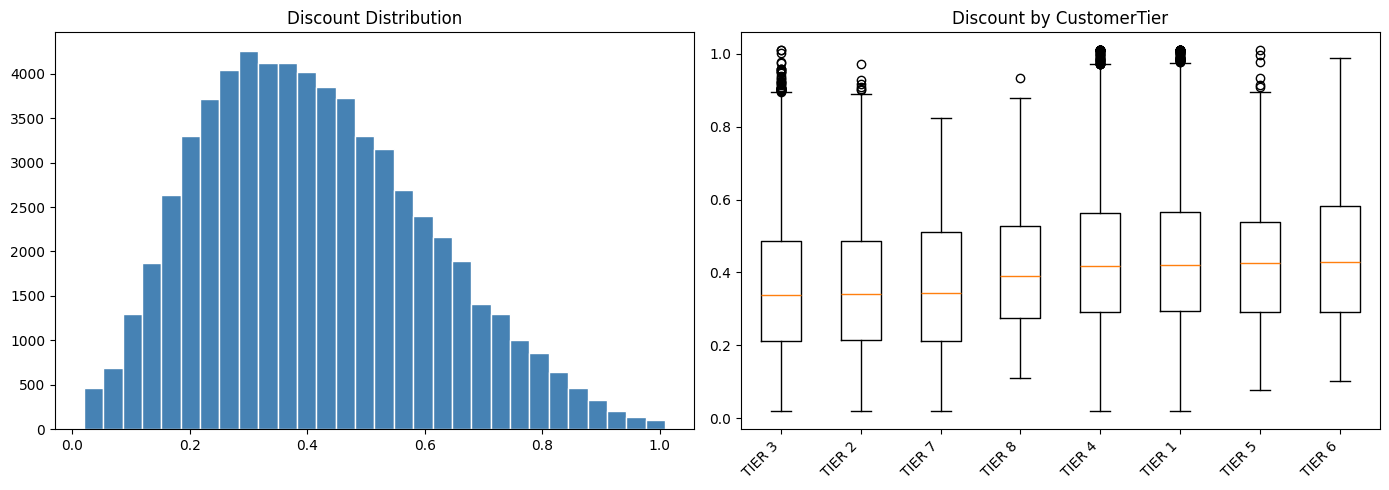

In [67]:
df = pd.read_excel(DATA_FILE)

# If Excel has duplicate headers (for example CustomerTier repeated), make them unique first.
if df.columns.duplicated().any():
    seen = {}
    unique_cols = []
    for col in df.columns:
        if col not in seen:
            seen[col] = 0
            unique_cols.append(col)
        else:
            seen[col] += 1
            unique_cols.append(f'{col}_{seen[col]}')
    df.columns = unique_cols

# If CustomerTier appears twice, treat the second one as EndCustomerTier.
if 'CustomerTier_1' in df.columns and 'EndCustomerTier' not in df.columns:
    df = df.rename(columns={'CustomerTier_1': 'EndCustomerTier'})

COLS = {
    'market': 'Market',
    'approval_date': 'ApprovalDate',
    'product_group': 'ProductGroup',
    'customer_tier': 'CustomerTier',
    'customer_tier_secondary': 'EndCustomerTier' if 'EndCustomerTier' in df.columns else None,
    'quantity_bin': 'QuantityBin',
    'product': 'Product',
    'submarket': 'SubMarket',
    'region': 'Region',
    'customer': 'Customer',
    'discount': 'Discount',
    'tier_rank': 'CustomerTierRank'
}

required_cols = [
    COLS['market'], COLS['approval_date'], COLS['product_group'], COLS['customer_tier'],
    COLS['quantity_bin'], COLS['product'], COLS['submarket'], COLS['region'],
    COLS['customer'], COLS['discount'], COLS['tier_rank']
 ]
missing_cols = [c for c in required_cols if c not in df.columns]
if missing_cols:
    raise ValueError(f"Missing required new columns: {missing_cols}")

df[COLS['approval_date']] = pd.to_datetime(df[COLS['approval_date']], errors='coerce')

print(f"Shape: {df.shape[0]:,} rows x {df.shape[1]} columns")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].hist(df[COLS['discount']].dropna(), bins=30, color='steelblue', edgecolor='white')
axes[0].set_title('Discount Distribution')

tier_order = df.groupby(COLS['customer_tier'])[COLS['discount']].median().sort_values().index.tolist()
plot_data = [df.loc[df[COLS['customer_tier']] == t, COLS['discount']].dropna().values for t in tier_order]
axes[1].boxplot(plot_data, labels=tier_order)
axes[1].set_title('Discount by CustomerTier')
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

## Stage 2: Feature Engineering & Encoding

In [68]:
def parse_qty_bin(val):
    if pd.isna(val): return np.nan
    match = re.search(r'(\d+)', str(val))
    return int(match.group(1)) if match else np.nan

df['QTY_BIN_NUM'] = df[COLS['quantity_bin']].apply(parse_qty_bin)

CAT_COLS = [
    COLS['market'], COLS['submarket'], COLS['product_group'],
    COLS['product'], COLS['region'], COLS['customer_tier'], COLS['customer']
 ]
if COLS['customer_tier_secondary'] is not None:
    CAT_COLS.append(COLS['customer_tier_secondary'])
CAT_COLS = [c for c in CAT_COLS if c is not None]

encoders = {}
for col in CAT_COLS:
    if col in df.columns:
        le = LabelEncoder()
        df[f'{col}_enc'] = le.fit_transform(df[col].fillna('UNKNOWN').astype(str))
        encoders[col] = le

FEATURE_COLS = [
    f"{COLS['market']}_enc", f"{COLS['submarket']}_enc", f"{COLS['product_group']}_enc",
    f"{COLS['product']}_enc", f"{COLS['region']}_enc", f"{COLS['customer_tier']}_enc",
    COLS['tier_rank'], 'QTY_BIN_NUM', f"{COLS['customer']}_enc"
 ]
if COLS['customer_tier_secondary'] is not None:
    FEATURE_COLS.insert(6, f"{COLS['customer_tier_secondary']}_enc")

if COLS['approval_date'] is not None:
    df_sorted = df.dropna(subset=[COLS['discount']]).sort_values(COLS['approval_date']).reset_index(drop=True)
else:
    df_sorted = df.dropna(subset=[COLS['discount']]).reset_index(drop=True)

split_idx = int(len(df_sorted) * (1 - TEST_SIZE))
df_train = df_sorted.iloc[:split_idx].copy()
df_test = df_sorted.iloc[split_idx:].copy()

## Stage 3: Customer Segmentation

In [69]:
cust_features = df.groupby(COLS['customer']).agg(
    avg_discount=(COLS['discount'], 'mean'),
    market_breadth=(COLS['market'], 'nunique'),
    avg_tier_rank=(COLS['tier_rank'], 'mean')
).fillna(0).reset_index()

X_cust = cust_features.drop(columns=[COLS['customer']])
scaler = StandardScaler()
X_cust_scaled = scaler.fit_transform(X_cust)

kmeans = KMeans(n_clusters=4, random_state=RANDOM_STATE, n_init=10)
cust_features['BEHAVIORAL_CLUSTER'] = kmeans.fit_predict(X_cust_scaled)

cluster_map = cust_features.set_index(COLS['customer'])['BEHAVIORAL_CLUSTER'].to_dict()
for target in [df_sorted, df_train, df_test]:
    target['BEHAVIORAL_CLUSTER'] = target[COLS['customer']].map(cluster_map).fillna(-1).astype(int)

FEATURE_COLS_FINAL = FEATURE_COLS + ['BEHAVIORAL_CLUSTER']

## Stage 4: Model Configuration

In [70]:
MODEL_CONFIG = {
    'quantiles': [0.10, 0.25, 0.50, 0.75, 0.90],
    'n_estimators': 500,
    'max_depth': 6,
    'learning_rate': 0.05,
    'random_state': RANDOM_STATE
}

# Build constraints dynamically so size always matches active feature count.
constraint_map = {feature: 0 for feature in FEATURE_COLS_FINAL}
for monotone_up_feature in [COLS['tier_rank'], 'QTY_BIN_NUM']:
    if monotone_up_feature in constraint_map:
        constraint_map[monotone_up_feature] = 1
MONOTONE_CONSTRAINTS = tuple(constraint_map[feature] for feature in FEATURE_COLS_FINAL)

X_train, y_train = df_train[FEATURE_COLS_FINAL].fillna(0), df_train[COLS['discount']]
X_test, y_test = df_test[FEATURE_COLS_FINAL].fillna(0), df_test[COLS['discount']]
print(f'Using {len(FEATURE_COLS_FINAL)} features with {len(MONOTONE_CONSTRAINTS)} monotone constraints')

Using 10 features with 10 monotone constraints


## Stage 5: ML Guidance Generation

In [71]:
models = {}
QUANTILE_OVERRIDES = {0.10: (0.1, 2), 0.25: (0.3, 2), 0.50: (1.0, 5), 0.75: (1.0, 5), 0.90: (0.5, 3)}

for q in MODEL_CONFIG['quantiles']:
    label = f'P{int(q * 100)}'
    reg_lam, mcw = QUANTILE_OVERRIDES[q]
    m = XGBRegressor(objective='reg:quantileerror', quantile_alpha=q, 
                     monotone_constraints=MONOTONE_CONSTRAINTS, reg_lambda=reg_lam,
                     min_child_weight=mcw, **{k:v for k,v in MODEL_CONFIG.items() if k!='quantiles'})
    m.fit(X_train, y_train)
    models[label] = m
    print(f'Trained {label}')

Trained P10
Trained P25
Trained P50
Trained P75
Trained P90


## Stage 6: Rationalization Check

In [72]:
CALIB_FRAC = 0.15
n_calib = int(len(df_train) * CALIB_FRAC)
X_calib = df_train.iloc[-n_calib:][FEATURE_COLS_FINAL].fillna(0)
y_calib = df_train.iloc[-n_calib:][COLS['discount']]

cqr_offsets = {}
for q, label in zip(MODEL_CONFIG['quantiles'], ['P10', 'P25', 'P50', 'P75', 'P90']):
    preds_calib = models[label].predict(X_calib)
    scores = y_calib.values - preds_calib
    cqr_offsets[label] = np.percentile(scores, q * 100)

preds_df = df_test[[COLS['discount']]].copy().rename(columns={COLS['discount']: 'ACTUAL'})
for label, model in models.items():
    preds_df[label] = (model.predict(X_test) + cqr_offsets[label]).clip(0, 0.99)

q_cols = ['P10', 'P25', 'P50', 'P75', 'P90']
before_crossing = (
    (preds_df['P10'] > preds_df['P25']) | (preds_df['P25'] > preds_df['P50']) |
    (preds_df['P50'] > preds_df['P75']) | (preds_df['P75'] > preds_df['P90'])
).mean() * 100

# Enforce non-crossing bands and a small minimum gap.
min_gap = 0.005
band_values = preds_df[q_cols].to_numpy()
band_values = np.maximum.accumulate(band_values, axis=1)
for i in range(1, band_values.shape[1]):
    band_values[:, i] = np.maximum(band_values[:, i], band_values[:, i - 1] + min_gap)
preds_df[q_cols] = np.clip(band_values, 0, 0.99)

after_crossing = (
    (preds_df['P10'] > preds_df['P25']) | (preds_df['P25'] > preds_df['P50']) |
    (preds_df['P50'] > preds_df['P75']) | (preds_df['P75'] > preds_df['P90'])
).mean() * 100

print(f'Crossing rate before check: {before_crossing:.2f}%')
print(f'Crossing rate after check:  {after_crossing:.2f}%')

Crossing rate before check: 0.32%
Crossing rate after check:  0.00%


## Stage 7: Guidance Lookup

Evaluation Summary


,Metric,Value,Target,Status
0,Coverage (P10-P90),78.25,~80%,OK
1,Latest Rolling 90D Coverage,78.13,~80%,OK
2,Crossing Rate After Check,0.00,0%,OK


Pinball Loss by Quantile


,Quantile,PinballLoss
0,P10,0.027561
1,P25,0.055379
2,P50,0.075500
3,P75,0.063223
4,P90,0.035372


Zone Distribution (%)


,Zone,Pct
0,Dark Green,10.86
1,Green,14.97
2,Yellow,24.35
3,Orange,24.17
4,Red,14.76
5,Above Red,10.89


Sample Guidance Output


,ApprovalDate,Customer,Market,SubMarket,ProductGroup,Product,CustomerTier,QuantityBin,ACTUAL,P10,P25,P50,P75,P90,Zone,Driver_1,Driver_2,Driver_3
0,2021-10-19,Customer 5062,Market 9,Sub-Market 67,GROUP-D,Family-05,TIER 4,17,0.473619,0.214809,0.285902,0.347892,0.513052,0.623052,Orange,BEHAVIORAL_CLUSTER: -6.6pp,QTY_BIN_NUM: +3.6pp,CustomerTierRank: +2.5pp
1,2021-10-19,Customer 1715,Market 4,Sub-Market 37,GROUP-A,Family-01,TIER 4,4,0.364460,0.185527,0.278834,0.388743,0.527904,0.692518,Yellow,CustomerTierRank: +2.1pp,QTY_BIN_NUM: -1.4pp,SubMarket_enc: -1.1pp
2,2021-10-19,Customer 5584,Market 4,Sub-Market 31,GROUP-A,Family-04,TIER 3,12,0.414543,0.142372,0.203248,0.330516,0.487094,0.610381,Orange,CustomerTierRank: -5.0pp,BEHAVIORAL_CLUSTER: -1.9pp,QTY_BIN_NUM: +1.1pp
3,2021-10-19,Customer 3030,Market 1,Sub-Market 1,GROUP-E,Family-07,TIER 1,5,0.369059,0.194710,0.267819,0.398728,0.538647,0.680726,Yellow,CustomerTierRank: +2.1pp,QTY_BIN_NUM: -1.4pp,Customer_enc: +0.4pp
4,2021-10-19,Customer 14,Market 1,Sub-Market 1,GROUP-A,Family-18,TIER 1,1,0.526442,0.181383,0.275513,0.414050,0.539270,0.679037,Orange,QTY_BIN_NUM: -2.4pp,CustomerTierRank: +2.1pp,Customer_enc: +1.3pp
5,2021-10-19,Customer 3,Market 6,Sub-Market 48,GROUP-C,Family-04,TIER 4,7,0.453205,0.198899,0.287940,0.404302,0.543328,0.693517,Orange,CustomerTierRank: +2.2pp,SubMarket_enc: -0.7pp,Customer_enc: -0.3pp
6,2021-10-19,Customer 6928,Market 2,Sub-Market 16,GROUP-C,Family-07,TIER 1,5,0.310762,0.197281,0.266298,0.354350,0.487530,0.607964,Yellow,BEHAVIORAL_CLUSTER: -6.2pp,CustomerTierRank: +2.1pp,QTY_BIN_NUM: -1.9pp
7,2021-10-19,Customer 3211,Market 2,Sub-Market 14,GROUP-A,Family-11,TIER 1,7,0.723803,0.329049,0.477320,0.564241,0.681708,0.797818,Red,BEHAVIORAL_CLUSTER: +11.7pp,CustomerTierRank: +2.0pp,SubMarket_enc: +1.8pp
8,2021-10-19,Customer 6422,Market 6,Sub-Market 46,GROUP-C,Family-03,TIER 4,9,0.374986,0.206559,0.290554,0.396566,0.542958,0.679871,Yellow,CustomerTierRank: +2.4pp,SubMarket_enc: -1.9pp,QTY_BIN_NUM: +0.8pp
9,2021-10-19,Customer 3,Market 7,Sub-Market 56,GROUP-D,Family-07,TIER 4,8,0.492254,0.228908,0.329489,0.467247,0.577405,0.719238,Orange,CustomerTierRank: +2.4pp,Market_enc: +2.0pp,SubMarket_enc: +1.3pp


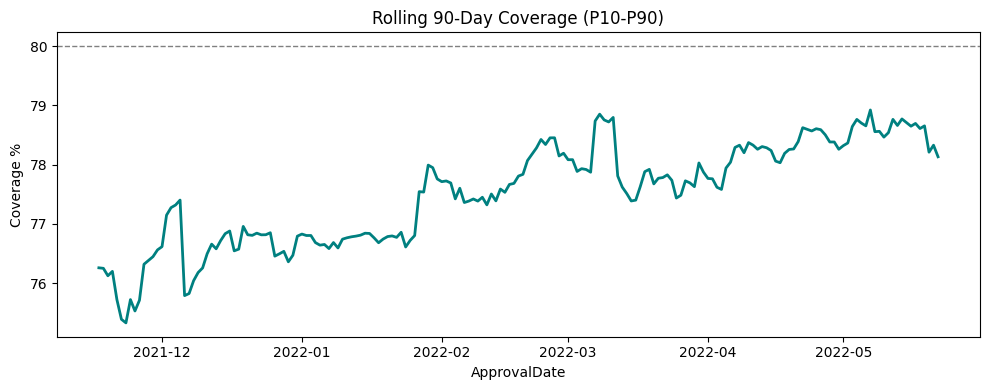

In [73]:
def pinball_loss(y_true, y_pred, q):
    err = y_true - y_pred
    return np.mean(np.maximum(q * err, (q - 1) * err))

def assign_zone(actual, p10, p25, p50, p75, p90):
    if actual <= p10:
        return 'Dark Green'
    if actual <= p25:
        return 'Green'
    if actual <= p50:
        return 'Yellow'
    if actual <= p75:
        return 'Orange'
    if actual <= p90:
        return 'Red'
    return 'Above Red'

guidance_cols = [
    COLS['approval_date'], COLS['customer'], COLS['market'], COLS['submarket'],
    COLS['product_group'], COLS['product'], COLS['customer_tier'], COLS['quantity_bin']
 ]
guidance_df = df_test[guidance_cols].copy().reset_index(drop=True)
guidance_df['ACTUAL'] = preds_df['ACTUAL'].values
for c in ['P10', 'P25', 'P50', 'P75', 'P90']:
    guidance_df[c] = preds_df[c].values

guidance_df['Zone'] = guidance_df.apply(
    lambda r: assign_zone(r['ACTUAL'], r['P10'], r['P25'], r['P50'], r['P75'], r['P90']), axis=1
)

explainer = shap.TreeExplainer(models['P50'])
shap_values = explainer(X_test)
sv = shap_values.values
feat_names = list(X_test.columns)
top_idx = np.argsort(np.abs(sv), axis=1)[:, -3:][:, ::-1]

for rank in range(3):
    col_name = f'Driver_{rank + 1}'
    guidance_df[col_name] = [
        f"{feat_names[top_idx[i, rank]]}: {sv[i, top_idx[i, rank]] * 100:+.1f}pp"
        for i in range(len(guidance_df))
    ]

# Stage 8: Validation Report
coverage = ((preds_df['ACTUAL'] >= preds_df['P10']) & (preds_df['ACTUAL'] <= preds_df['P90'])).mean() * 100
pinball = {
    f'P{int(q * 100)}': pinball_loss(preds_df['ACTUAL'].values, preds_df[f'P{int(q * 100)}'].values, q)
    for q in MODEL_CONFIG['quantiles']
}

zone_order = ['Dark Green', 'Green', 'Yellow', 'Orange', 'Red', 'Above Red']
zone_dist = (guidance_df['Zone'].value_counts(normalize=True) * 100).reindex(zone_order, fill_value=0).round(2)

daily = guidance_df[[COLS['approval_date'], 'ACTUAL', 'P10', 'P90']].copy()
daily = daily.rename(columns={COLS['approval_date']: 'ApprovalDate'}).dropna(subset=['ApprovalDate'])
daily['in_band'] = ((daily['ACTUAL'] >= daily['P10']) & (daily['ACTUAL'] <= daily['P90'])).astype(int)
daily_coverage = daily.groupby('ApprovalDate')['in_band'].mean().sort_index()
rolling_90d_coverage = daily_coverage.rolling(90, min_periods=30).mean() * 100
latest_rolling_cov = rolling_90d_coverage.dropna().iloc[-1] if len(rolling_90d_coverage.dropna()) > 0 else np.nan

pinball_df = pd.DataFrame({
    'Quantile': list(pinball.keys()),
    'PinballLoss': [pinball[k] for k in pinball.keys()]
}).sort_values('Quantile').reset_index(drop=True)

summary_df = pd.DataFrame([
    {'Metric': 'Coverage (P10-P90)', 'Value': round(float(coverage), 2), 'Target': '~80%', 'Status': 'OK' if coverage >= 78 else 'Watch'},
    {'Metric': 'Latest Rolling 90D Coverage', 'Value': round(float(latest_rolling_cov), 2) if pd.notna(latest_rolling_cov) else np.nan, 'Target': '~80%', 'Status': 'OK' if pd.notna(latest_rolling_cov) and latest_rolling_cov >= 78 else 'Watch'},
    {'Metric': 'Crossing Rate After Check', 'Value': round(float(after_crossing), 2), 'Target': '0%', 'Status': 'OK' if after_crossing == 0 else 'Watch'}
])

print('Evaluation Summary')
display(summary_df)

print('Pinball Loss by Quantile')
display(pinball_df)

print('Zone Distribution (%)')
display(zone_dist.rename_axis('Zone').reset_index(name='Pct'))

print('Sample Guidance Output')
display(guidance_df.head(10))

plt.figure(figsize=(10, 4))
plt.plot(rolling_90d_coverage.index, rolling_90d_coverage.values, color='teal', linewidth=2)
plt.axhline(80, color='gray', linestyle='--', linewidth=1)
plt.title('Rolling 90-Day Coverage (P10-P90)')
plt.ylabel('Coverage %')
plt.xlabel('ApprovalDate')
plt.tight_layout()
plt.show()